In [83]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')


In [84]:
df=pd.read_csv('/train_u6lujuX_CVtuZ9i.csv')


#EDA

In [85]:
#EDA

df.head() #Shows first 5 rows




,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [86]:
df.columns #Shows column names

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [87]:
df['Dependents'].value_counts()
# Counts how many times each value appears in the 'Dependents' column.
# Useful to check which category occurs most often (mode), which helps when handling missing values.


,count
Dependents,
0,345
1,102
2,101
3+,51


In [88]:
df.shape #Shows how much rows and columns we have

(614, 13)

In [89]:
df.info() #Shows information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [90]:
df.describe()
# Shows summary statistics of numerical columns.
# Helps understand the data before analysis.

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [91]:
df.isnull().sum() #Shows null values

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


#Handling missing values


In [92]:
df_clean = df.drop('Loan_ID', axis=1)

# Removes Loan_ID because it is only an identifier.
# It does not help in prediction.

In [93]:
df_clean['Gender']=df_clean['Gender'].fillna(df_clean['Gender'].mode()[0])

# We use mode because 'Gender' is categorical.
# Missing values are filled with the most frequent category.

In [94]:
df_clean['Dependents']=df['Dependents'].replace('3+',3)

# Replaces '3+' with 3 to make the column numeric.
# Models work better with numerical values

In [95]:
df_clean['Dependents']=df_clean['Dependents'].fillna(df_clean['Dependents'].mode()[0])

# We use mode because 'Dependents' is mostly category-like here.
# Missing values are filled with the most common value

In [96]:
df_clean['Self_Employed']=df_clean['Self_Employed'].fillna(df_clean['Self_Employed'].mode()[0])

# We use mode because 'Self_Employed' is categorical.
# Missing values are filled with the most frequent category.

In [97]:
df_clean['Dependents']=pd.to_numeric(df_clean['Dependents'])

# Converts the column to numeric type.
# Needed for calculations and model training.

In [98]:
df_clean['Dependents'].unique()



array([0, 1, 2, 3])

In [99]:
df_clean['Dependents']=df_clean['Dependents'].astype('Int64')
 # Converts values into integer format.
# Dependents should be whole numbers, not decimals.

In [100]:
df_clean['LoanAmount']=df_clean['LoanAmount'].fillna(df_clean['LoanAmount'].median())

# We use median because LoanAmount is numerical.
# Median handles outliers better than mean.

In [101]:
df_clean['Loan_Amount_Term']=df_clean['Loan_Amount_Term'].fillna(df_clean['Loan_Amount_Term'].median())

# We use median because this is a numerical column.
# Median is safer when extreme values are present

In [102]:
df_clean['Credit_History']=df_clean['Credit_History'].fillna(df['Credit_History'].mode()[0])

# We use mode because Credit_History has limited category values.
# Missing values are filled with the most common class.

In [103]:
df_clean['Married']=df_clean['Married'].fillna(df['Married'].mode()[0])

# We use mode because Married is categorical.
# Missing values are filled with the most frequent category.

#Encoding :
Converts categorical text into numbers Machine learning models cannot directly use text values.


In [104]:
encoded_data = pd.get_dummies(df_clean, columns=['Gender'], drop_first=True)
encoded_data

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Gender_Male
0,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,True
1,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,True
2,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,True
3,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,True
4,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,True
...,...,...,...,...,...,...,...,...,...,...,...,...
609,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,False
610,Yes,3,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,True
611,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,True
612,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,True


In [105]:
encoded_data['Education']=encoded_data['Education'].map({'Not Graduate':0,'Graduate':1})

In [106]:
encoded_data['Self_Employed']=encoded_data['Self_Employed'].map({'No':0,'Yes':1})

In [107]:
encoded_data['Married']=encoded_data['Married'].map({'No':0, 'Yes':1})

In [108]:
encoded_data=pd.get_dummies(encoded_data, columns=['Property_Area'])

In [109]:
encoded_data['Loan_Status']=encoded_data['Loan_Status'].map({'N':0, 'Y':1})

In [110]:
encoded_data

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,True,False,False,True
1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,True,True,False,False
2,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,True,False,False,True
3,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,True,False,False,True
4,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,1,0,2900,0.0,71.0,360.0,1.0,1,False,True,False,False
610,1,3,1,0,4106,0.0,40.0,180.0,1.0,1,True,True,False,False
611,1,1,1,0,8072,240.0,253.0,360.0,1.0,1,True,False,False,True
612,1,2,1,0,7583,0.0,187.0,360.0,1.0,1,True,False,False,True


In [111]:
df2=encoded_data.drop_duplicates() # Removes duplicate rows. Duplicate data can affect model performance.

#Logistic Regression



In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

Training Score: 0.8217391304347826
Testing Score: 0.7727272727272727

              precision    recall  f1-score   support

           0       0.91      0.39      0.55        54
           1       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154



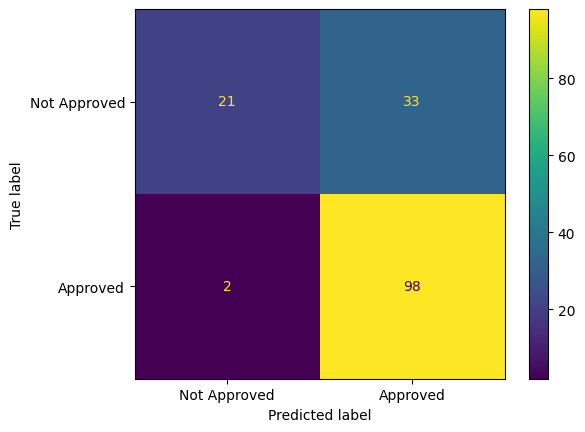

In [113]:
X=df2.drop('Loan_Status',axis=1)
y=df2['Loan_Status']

X_train, x_test, y_train, y_test=train_test_split(X,y,test_size=0.25,random_state=42)

scaler=MinMaxScaler()
scaler.fit(X_train)
X_train= scaler.transform(X_train)
x_test= scaler.transform(x_test)

lr=LogisticRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(x_test)

print("Training Score:", lr.score(X_train, y_train))
print("Testing Score:", lr.score(x_test, y_test))
print()

print(classification_report(y_test, y_pred))
cm=confusion_matrix(y_test,y_pred)
print("="*60)
dis=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels = ['Not Approved', 'Approved'])
dis.plot()
plt.show()

#Decision Tree

In [114]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import plot_tree

Training Score: 0.8152173913043478
Testing Score: 0.7337662337662337



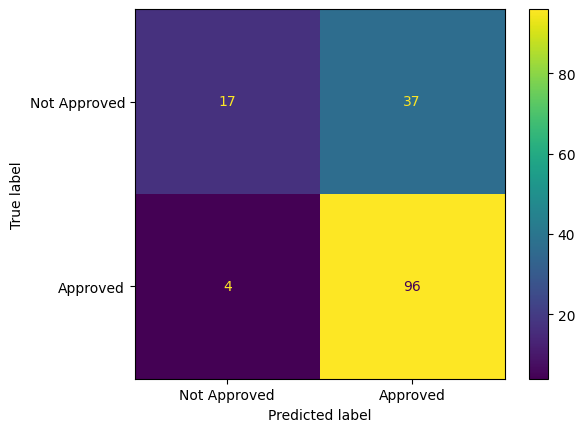

In [115]:
X=df2.drop('Loan_Status',axis=1)
y=df2['Loan_Status']

X_train, x_test, y_train, y_test=train_test_split(X,y,test_size=0.25,random_state=42)

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    max_leaf_nodes=7,
    max_features='sqrt',
    splitter='best',
    random_state=42
)

model.fit(X_train, y_train)

y_pred=model.predict(x_test)

print("Training Score:", model.score(X_train, y_train))
print("Testing Score:", model.score(x_test, y_test))
print()
cm=confusion_matrix(y_test,y_pred)
dis=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels = ['Not Approved', 'Approved'])
dis.plot()
plt.show()

#KNN

In [116]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

Training Score: 0.8152173913043478
Testing Score: 0.7597402597402597



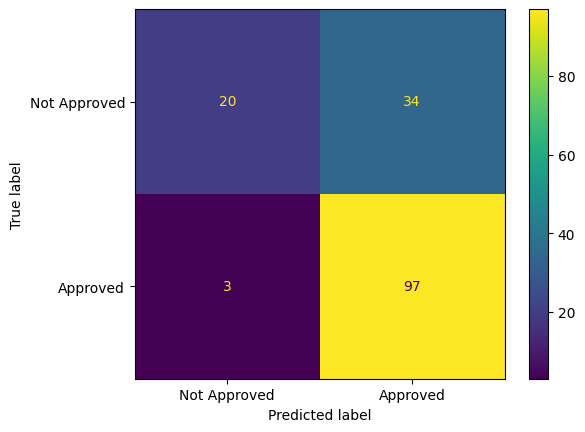

In [117]:
X=df2.drop('Loan_Status',axis=1)
y=df2['Loan_Status']

X_train, x_test, y_train, y_test=train_test_split(X,y,test_size=0.25,random_state=42)

scaler=MinMaxScaler()
scaler.fit(X_train)
X_train= scaler.transform(X_train)
x_test= scaler.transform(x_test)

kn = KNeighborsClassifier(n_neighbors=7)
kn.fit(X_train, y_train)
y_pred=kn.predict(x_test)

print("Training Score:", kn.score(X_train, y_train))
print("Testing Score:", kn.score(x_test, y_test))
print()
cm=confusion_matrix(y_test,y_pred)
dis=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels = ['Not Approved', 'Approved'])
dis.plot()
plt.show()

#SVM

In [118]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

RBF Train Score: 0.8304347826086956
RBF Test Score : 0.7792207792207793

Naive Bayes Train Score: 0.8108695652173913
Naive Bayes Test Score : 0.7792207792207793


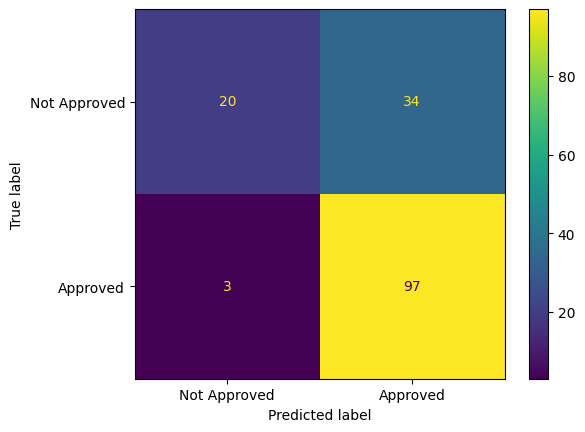

In [119]:
X=df2.drop('Loan_Status',axis=1)
y=df2['Loan_Status']

X_train, x_test, y_train, y_test=train_test_split(X,y,test_size=0.25,random_state=42)

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(x_test)

model2 = SVC(kernel='rbf', C=1, gamma='scale')
model2.fit(X_train, y_train)

print("RBF Train Score:", model2.score(X_train, y_train))
print("RBF Test Score :", model2.score(X_test, y_test))

print()

# Naive Bayes (GaussianNB)


model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

print("Naive Bayes Train Score:", model_nb.score(X_train, y_train))
print("Naive Bayes Test Score :", model_nb.score(X_test, y_test))
cm=confusion_matrix(y_test,y_pred)
dis=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels = ['Not Approved', 'Approved'])
dis.plot()
plt.show()

#Random Tree

Best Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 3, 'max_depth': 5}
Train Score With Random Search: 0.8217391304347826
Test Score With Random Search: 0.7727272727272727

              precision    recall  f1-score   support

           0       0.91      0.39      0.55        54
           1       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154



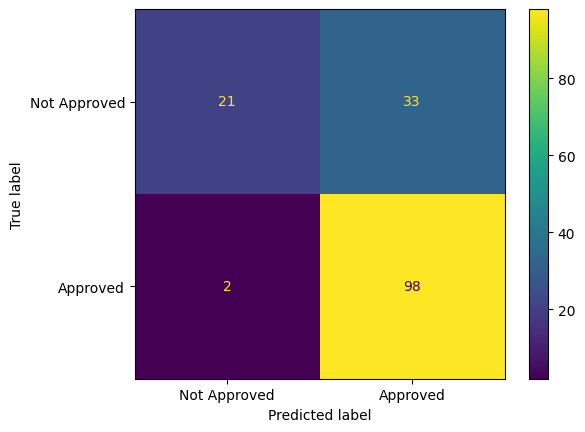

Best Parameters with GridSearch: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Training Score with GridSearch: 0.8239130434782609
Testing Score with GridSearch: 0.7727272727272727

              precision    recall  f1-score   support

           0       0.91      0.39      0.55        54
           1       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154



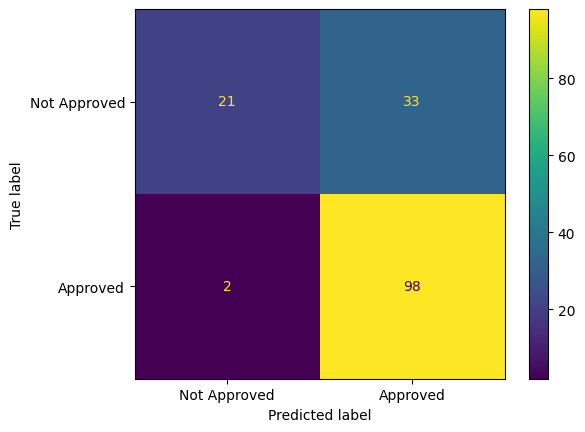

In [120]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

rf=RandomForestClassifier(random_state=42)

X=df2.drop('Loan_Status',axis=1)
y=df2['Loan_Status']

X_train, x_test, y_train, y_test=train_test_split(X,y,test_size=0.25,random_state=42)

param_dist = {
    'n_estimators': [50,100,200,300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2,3,5,10],
    'min_samples_leaf':[1,2,4,5],
    'max_features':['sqrt',2,3,5],
}
# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42
)
# Train
random_search.fit(X_train, y_train)

# Best model
best_model = random_search.best_estimator_
y_pred=best_model.predict(x_test)

print("Best Params:", random_search.best_params_)
print("Train Score With Random Search:", best_model.score(X_train, y_train))
print("Test Score With Random Search:", best_model.score(x_test, y_test))

print()
print(classification_report(y_test, y_pred))
cm=confusion_matrix(y_test,y_pred)
print("="*60)
dis=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels = ['Not Approved', 'Approved'])
dis.plot()
plt.show()

# GridSearch

param_grid = {
    'n_estimators': [50, 100, 200,300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2,3,5,10],
    'min_samples_leaf': [1,2,4,5],
    'max_features':['sqrt',2,3,5]}


grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

# Predictions
y_pred = best_model.predict(x_test)

# Results
print("Best Parameters with GridSearch:", grid_search.best_params_)
print("Training Score with GridSearch:", best_model.score(X_train, y_train))
print("Testing Score with GridSearch:", best_model.score(x_test, y_test))
print()
print(classification_report(y_test, y_pred))
cm=confusion_matrix(y_test,y_pred)
print("="*60)
dis=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels = ['Not Approved', 'Approved'])
dis.plot()
plt.show()



#AdaBoost

Best Params: {'n_estimators': 50, 'learning_rate': 0.05, 'estimator__max_depth': 1}
Train Score With Random Search: 0.8217391304347826
Test Score With Random Search: 0.7727272727272727
              precision    recall  f1-score   support

           0       0.91      0.39      0.55        54
           1       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154



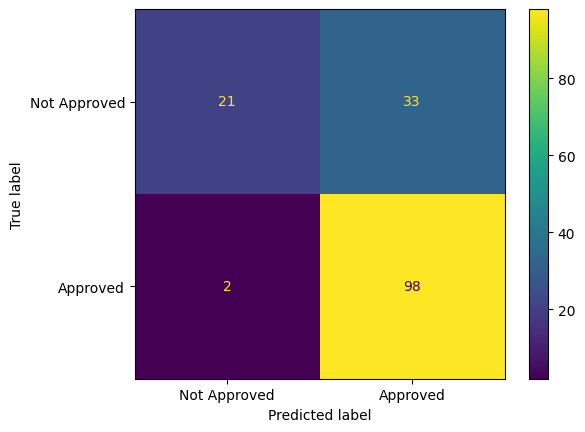

In [122]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

base_model = DecisionTreeClassifier(max_depth=1)

X=df2.drop('Loan_Status',axis=1)
y=df2['Loan_Status']
X_train, x_test, y_train, y_test=train_test_split(X,y,test_size=0.25,random_state=42)

ada = AdaBoostClassifier(estimator=base_model, random_state=42)
param_dist ={
    'n_estimators': [50,100,200,300],
    'learning_rate': [0.05,0.1,0.5,1],  #0-1
    'estimator__max_depth': [1, 2, 3, 5]
}
random_search = RandomizedSearchCV(
    estimator=ada,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42
)
random_search.fit(X_train,y_train)
best_model = random_search.best_estimator_

y_pred=best_model.predict(x_test)

print("Best Params:", random_search.best_params_)
print("Train Score With Random Search:", best_model.score(X_train, y_train))
print("Test Score With Random Search:", best_model.score(x_test, y_test))

print(classification_report(y_test,y_pred))
cm=confusion_matrix(y_test,y_pred)
dis=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels = ['Not Approved', 'Approved'])
dis.plot()
plt.show()

#Gradient Boost

Best Params: {'random_state': 42, 'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.01}
Train Score With Random Search: 0.8217391304347826
Test Score With Random Search: 0.7727272727272727
              precision    recall  f1-score   support

           0       0.91      0.39      0.55        54
           1       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154



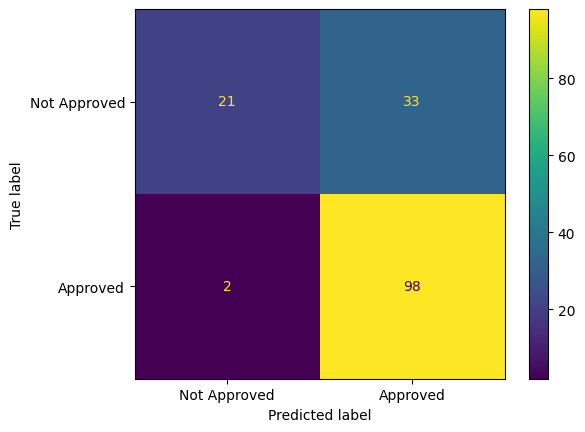

In [123]:
X=df2.drop('Loan_Status',axis=1)
y=df2['Loan_Status']
X_train, x_test, y_train, y_test=train_test_split(X,y,test_size=0.25,random_state=42)

gb_model= GradientBoostingClassifier()

param_dist={
    'n_estimators':[50,100,150,200],
    'learning_rate':[0.01,0.05,0.1,1],
    'max_depth':[2,3,5,7,10],
    'random_state':[42]
}
random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42
)
random_search.fit(X_train,y_train)
G_model = random_search.best_estimator_

y_pred=G_model.predict(x_test)
print("Best Params:", random_search.best_params_)
print("Train Score With Random Search:", G_model.score(X_train, y_train))
print("Test Score With Random Search:", G_model.score(x_test, y_test))

print(classification_report(y_test,y_pred))

cm=confusion_matrix(y_test,y_pred)
dis=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels = ['Not Approved', 'Approved'])
dis.plot()
plt.show()

#XGboost

Best Params: {'subsample': 0.8, 'random_state': 42, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 3, 'colsample_bytree': 1.0}
Train Score With Random Search: 0.8217391304347826
Test Score With Random Search: 0.7727272727272727
              precision    recall  f1-score   support

           0       0.91      0.39      0.55        54
           1       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154



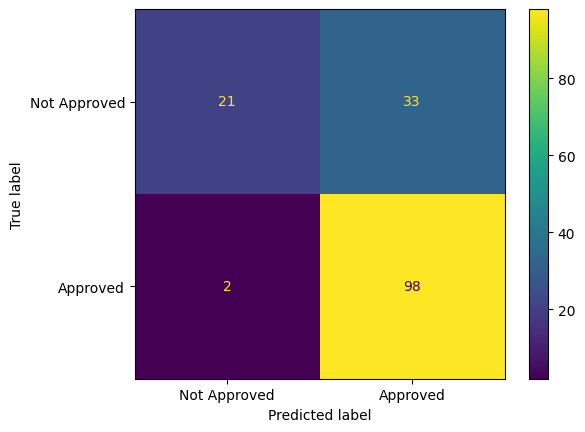

In [124]:
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

X=df2.drop('Loan_Status',axis=1)
y=df2['Loan_Status']
X_train, x_test, y_train, y_test=train_test_split(X,y,test_size=0.25,random_state=42)

XG_model= XGBClassifier()

param_dist={'n_estimators':[100,200,500],
    'learning_rate':[0.01,0.05,0.5,1],
    'max_depth':[1,4,5,10],
    'random_state':[42],
    'subsample': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 3 , 5],
    'colsample_bytree': [0.6, 0.8, 1.0]
             }

random_search = RandomizedSearchCV(
    estimator=XG_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42
)
random_search.fit(X_train,y_train)

Xg= random_search.best_estimator_

y_pred=Xg.predict(x_test)
print("Best Params:", random_search.best_params_)
print("Train Score With Random Search:", Xg.score(X_train, y_train))
print("Test Score With Random Search:", Xg.score(x_test, y_test))

print(classification_report(y_test,y_pred))

cm=confusion_matrix(y_test,y_pred)
dis=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels = ['Not Approved', 'Approved'])
dis.plot()
plt.show()

#Catboost

Best Params: {'verbose': 0, 'random_state': 42, 'learning_rate': 0.01, 'l2_leaf_reg': 2, 'iterations': 500, 'early_stopping_rounds': 20, 'depth': 2}
Train Score With Random Search: 0.8239130434782609
Test Score With Random Search: 0.7727272727272727
              precision    recall  f1-score   support

           0       0.91      0.39      0.55        54
           1       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154



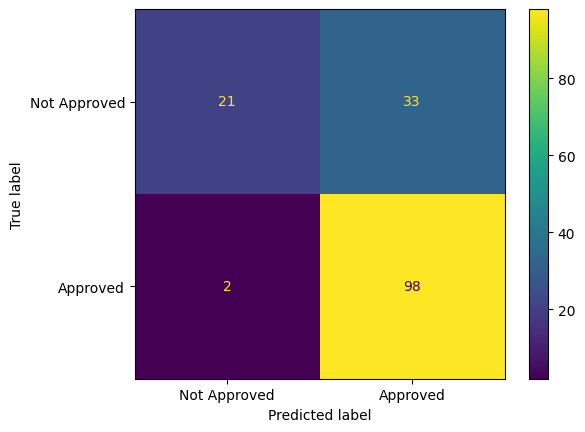

In [125]:
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

X=df2.drop('Loan_Status',axis=1)
y=df2['Loan_Status']
X_train, x_test, y_train, y_test=train_test_split(X,y,test_size=0.25,random_state=42)

cat_model = CatBoostClassifier()
param_dist= {
    'iterations':[50,100,200,500],
    'learning_rate':[0.01,0.05,0.5,1], # slower learning rate
    'depth':[1,2,3,5,10],
    'l2_leaf_reg':[1,2,3,5,7,10],  #regularization
    'early_stopping_rounds':[20],
    'verbose':[0],
    'random_state':[42]
}

random_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42
)
random_search.fit(X_train,y_train)

ct_boost= random_search.best_estimator_

y_pred=ct_boost.predict(x_test)
print("Best Params:", random_search.best_params_)
print("Train Score With Random Search:", ct_boost.score(X_train, y_train))
print("Test Score With Random Search:", ct_boost.score(x_test, y_test))

print(classification_report(y_test,y_pred))

cm=confusion_matrix(y_test,y_pred)
dis=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels = ['Not Approved', 'Approved'])
dis.plot()
plt.show()
